# Proof-of-Concept 4-Parameter Model

This notebook demonstrates a small proof-of-concept emulator that predicts the **binned kSZ angular power spectrum ($D_\ell$)** using 4 reionization params ($z_{mean}$, $\alpha$, $k_b$, $b_0$).

In [80]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
plt.rc("figure", figsize=(6, 4), dpi=150)

from reionemu import FourParamEmulator
from reionemu import DataLoaderConfig, make_dataloaders, load_training_arrays
from reionemu import FitConfig, fit

## File Paths
The condensed v6 simulation dataset is constructed with: $Y = \ln(D_\ell)$

In [81]:
H5_PATH = Path("../data/processed/condensed_v6.h5").resolve()
MODEL_PATH = Path("../checkpoints/poc_four_params/model.pt").resolve()
NORM_PATH = Path("../checkpoints/poc_four_params/norm/").resolve()

## Define Configs

In [82]:
dlcfg = DataLoaderConfig(
    batch_size=32,
    seed=42,
    shuffle_train=True,
    normalize_X=True,
    normalize_Y=False
)

fitcfg = FitConfig(
    epochs=200,
    device="mps",
    early_stopping_patience=50,
    gradient_clipping=None
)

## Prepare Data and Model

In [83]:
loaders, norms, ell = make_dataloaders(H5_PATH, split={"train": 0.8, "val": 0.2}, config=dlcfg)

model = FourParamEmulator()
lossfn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

model.eval()

FourParamEmulator(
  (fc1): Linear(in_features=4, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=5, bias=True)
  (activation): ReLU()
)

## Train Model

In [84]:
history = fit(model, loaders["train"], loaders["val"], optimizer, lossfn, config=fitcfg)

Epoch 001: train=1.000373, val=1.009083
Epoch 002: train=0.899523, val=0.863721
Epoch 003: train=0.724557, val=0.616929
Epoch 004: train=0.449554, val=0.307111
Epoch 005: train=0.195446, val=0.125052
Epoch 006: train=0.100074, val=0.086133
Epoch 007: train=0.077153, val=0.071779
Epoch 008: train=0.064747, val=0.061378
Epoch 009: train=0.054661, val=0.054330
Epoch 010: train=0.048063, val=0.048503
Epoch 011: train=0.043695, val=0.044540
Epoch 012: train=0.040806, val=0.041911
Epoch 013: train=0.038055, val=0.039730
Epoch 014: train=0.036436, val=0.038041
Epoch 015: train=0.035121, val=0.036858
Epoch 016: train=0.033576, val=0.035724
Epoch 017: train=0.032302, val=0.034483
Epoch 018: train=0.032148, val=0.034620
Epoch 019: train=0.030811, val=0.033113
Epoch 020: train=0.029897, val=0.032586
Epoch 021: train=0.028965, val=0.031395
Epoch 022: train=0.028553, val=0.030514
Epoch 023: train=0.027862, val=0.030844
Epoch 024: train=0.027690, val=0.029738
Epoch 025: train=0.027229, val=0.030143


## Save Model and Normalization

In [85]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

NORM_PATH.parent.mkdir(parents=True, exist_ok=True)
np.save(NORM_PATH / "X_mean.npy", norms["X"].mean)
np.save(NORM_PATH / "X_std.npy", norms["X"].std)
if dlcfg.normalize_Y == True:
    np.save(NORM_PATH / "Y_mean.npy", norms["Y"].mean)
    np.save(NORM_PATH / "Y_std.npy", norms["Y"].std)
np.save(NORM_PATH / "ell", np.asarray(ell))

Model saved to /Users/robertxpearce/Desktop/reionization-emulator/checkpoints/poc_four_params/model.pt


# Load Model and Normalization

In [86]:
device = torch.device("mps")

X_mean = np.load(f"{NORM_PATH}/X_mean.npy")
X_std  = np.load(f"{NORM_PATH}/X_std.npy")
Y_mean = np.load(f"{NORM_PATH}/Y_mean.npy")
Y_std  = np.load(f"{NORM_PATH}/Y_std.npy")
ell    = np.load(f"{NORM_PATH}/ell.npy")

model = FourParamEmulator().to(device)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

## Define Predict Function

In [87]:
def predict(params, model, X_mean, X_std, Y_mean=None, Y_std=None, normalize_Y=True):
    params = (params - X_mean) / X_std

    xb = torch.from_numpy(params).to(device)

    model.eval()
    with torch.no_grad():
        pred_norm = model(xb).cpu().numpy()

    if normalize_Y:
        pred_log = pred_norm * Y_std + Y_mean
    else:
        pred_log = pred_norm

    pred_dl = np.exp(pred_log)
    return pred_dl

## Error Metrics
- **Mean Squared Error (MSE)**: Computed in physical units $\mu K^2$ large errors are penalized.
- **Mean Absolute Error (MAE)**: Computed in physical units $\mu K^2$ errors are treated equally.

In [88]:
X, Y, ell = load_training_arrays(H5_PATH)


pred = []
true = []

if dlcfg.normalize_Y == True:
    pred = predict(X, model, X_mean, X_std, Y_mean, Y_std)
else:
    pred = predict(X, model, X_mean, X_std, normalize_Y=False)


true = np.exp(Y)

errors = np.abs((pred - true) / true)

mse = np.mean((pred - true)**2)
mae = np.mean(np.abs((pred - true)))
percent_err = np.mean(errors) * 100

bin_percent_err = np.mean(errors, axis=0) * 100

flat_idx = np.argmax(errors)
i, b = np.unravel_index(flat_idx, errors.shape)

print("Mean Squared Error (MSE):\t", mse)
print("Mean Absolute Error (MAE):\t", mae)
print("Mean % Error:\t\t\t\t", percent_err)
print()
print("Max % Error:\t\t\t\t", np.max(errors) * 100)
print("Mean % Error Per ell Bin:\t", bin_percent_err)
print()
print("Worst Case Sim:\t", i)
print("Worst Case Bin:\t", b)
print("True Dl:\t\t", true[i, b])
print("Pred Dl:\t\t", pred[i, b])
print("% error:\t\t", errors[i, b] * 100)

Mean Squared Error (MSE):	 0.0032924118
Mean Absolute Error (MAE):	 0.040444538
Mean % Error:				 4.313539

Max % Error:				 27.754698
Mean % Error Per ell Bin:	 [5.2855024 4.186626  4.1031713 3.988768  4.0036306]

Worst Case Sim:	 210
Worst Case Bin:	 0
True Dl:		 1.255212
Pred Dl:		 0.9068317
% error:		 27.754698


## Isolate Sim

In [89]:
sim_idx = 210

X, Y, ell = load_training_arrays(H5_PATH)
params = X[sim_idx]
true_dl = np.exp(Y[sim_idx])
pred_dl = predict(params, model, X_mean, X_std, Y_mean, Y_std)

print(f"Params:\t\t {params}")
print()
print(f"True:\t\t {true_dl}")
print(f"Predicted:\t {pred_dl}")

Params:		 [7.047597   0.7855842  1.6908534  0.31995168]

True:		 [1.255212   0.9633558  0.67719126 0.54858387 0.53951526]
Predicted:	 [0.90683174 0.779171   0.57559276 0.46483728 0.47463495]


## True vs Predicted $D_\ell$

Sim Index:		0
Params:			[7.3246355  0.48715696 0.25348133 0.71027094]
True Dl:		[1.4497963  1.1481824  0.8139568  0.66767186 0.66289914]
Predicted Dl:	[1.4667065  1.1362145  0.8177488  0.6593029  0.65866035]
% Error:		[ 1.1663842  -1.0423342   0.46587092 -1.2534554  -0.63943124]


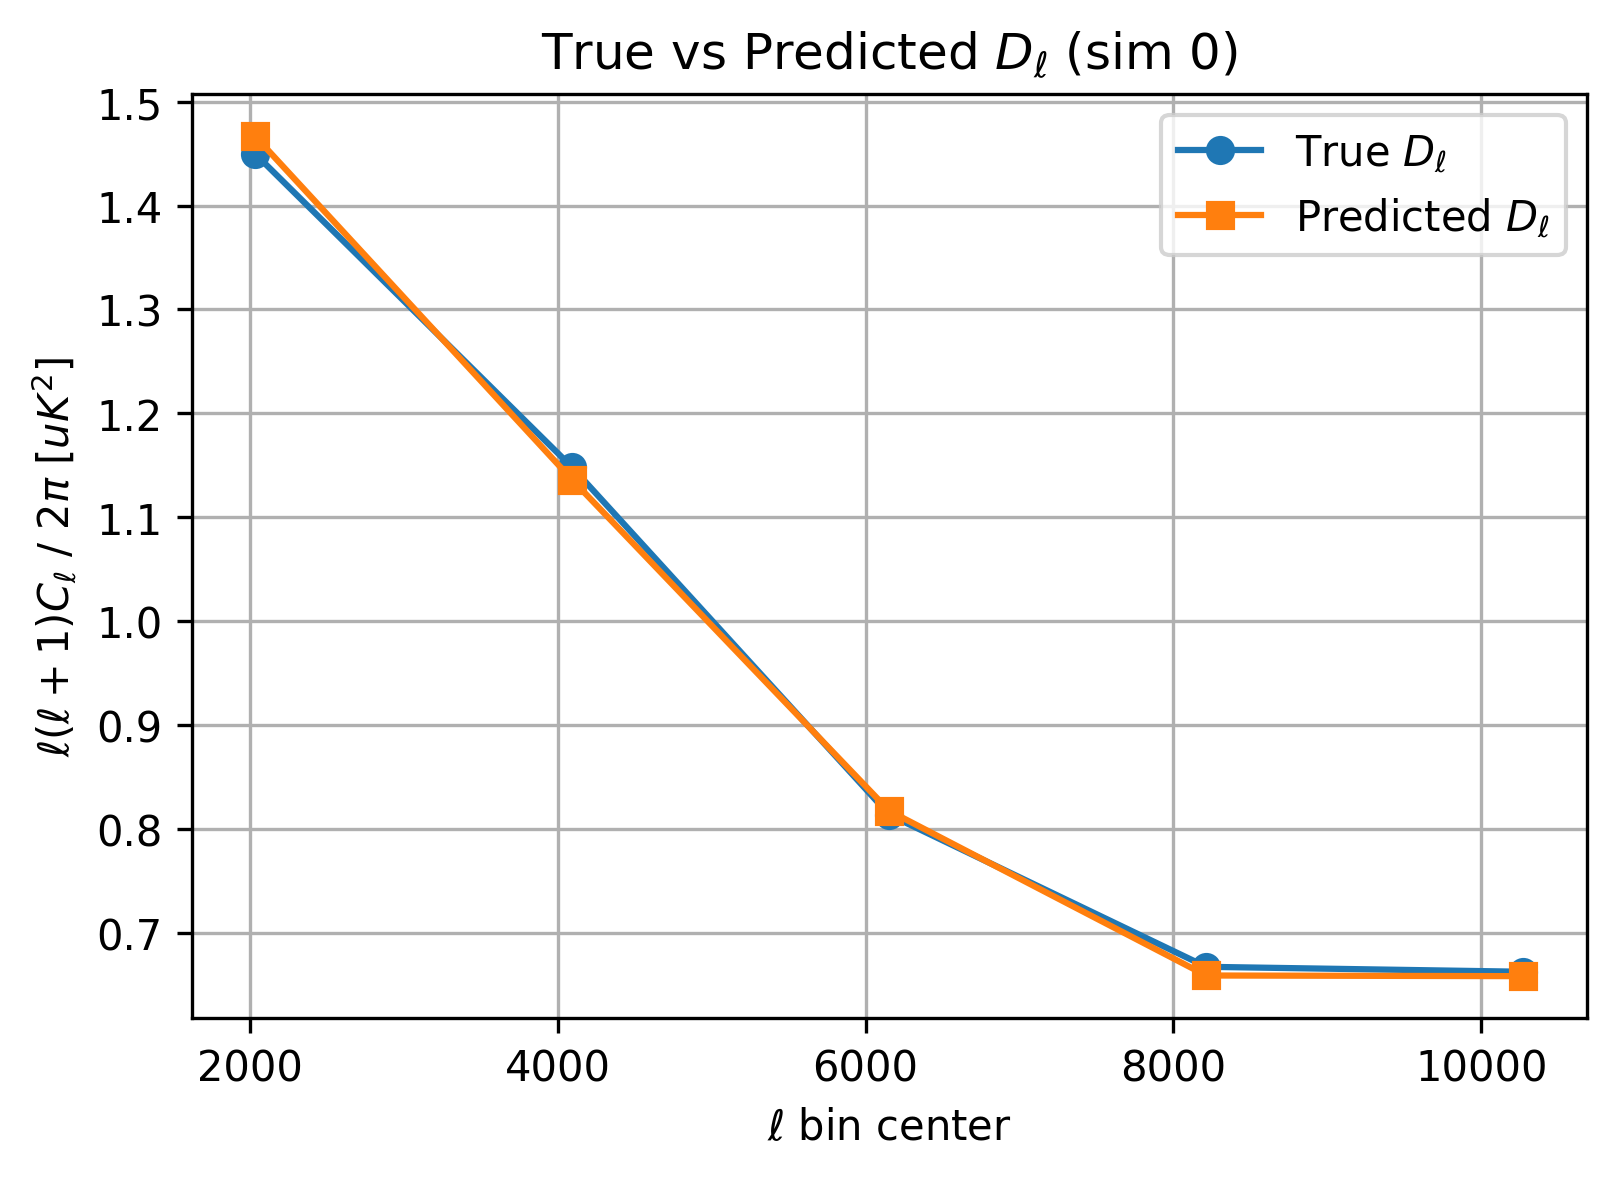

Sim Index:		210
Params:			[7.047597   0.7855842  1.6908534  0.31995168]
True Dl:		[1.255212   0.9633558  0.67719126 0.54858387 0.53951526]
Predicted Dl:	[0.90683174 0.779171   0.57559276 0.46483728 0.47463495]
% Error:		[-27.754692 -19.119083 -15.002926 -15.265959 -12.025668]


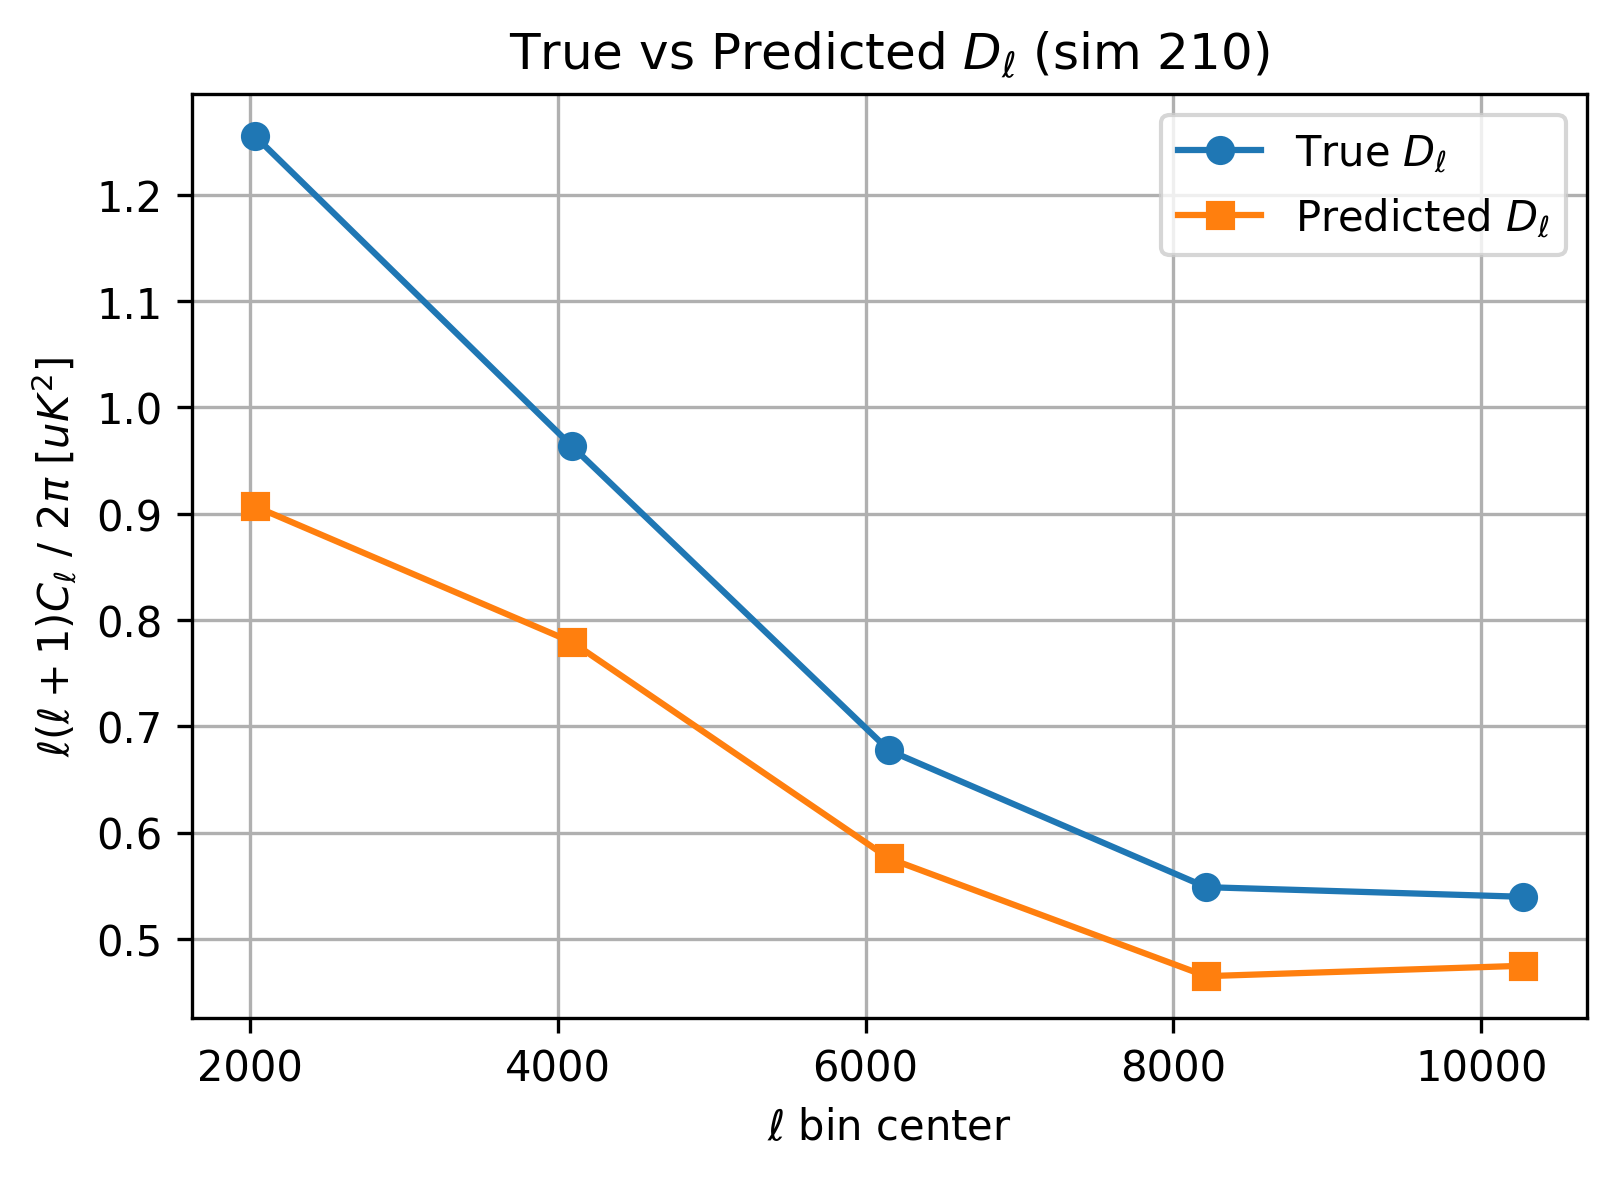

In [90]:
def plot_sim(sim_idx):
    X, Y, ell = load_training_arrays(H5_PATH)

    params = X[sim_idx]
    true_dl = np.exp(Y[sim_idx])
    pred_dl = predict(params, model, X_mean, X_std, Y_mean, Y_std)

    pct_err = 100.0 * (pred_dl - true_dl) / true_dl

    print(f"Sim Index:\t\t{sim_idx}")
    print(f"Params:\t\t\t{params}")
    print(f"True Dl:\t\t{true_dl}")
    print(f"Predicted Dl:\t{pred_dl}")
    print(f"% Error:\t\t{pct_err}")

    plt.plot(ell, true_dl, marker="o", label=r"True $D_\ell$")
    plt.plot(ell, pred_dl, marker="s", label=r"Predicted $D_\ell$")
    plt.xlabel(r"$\ell$ bin center")
    # plt.ylabel(r"$D_\ell$")
    plt.ylabel(r"$\ell (\ell + 1)C_{\ell}$ / $2 \pi$ [$uK^2$]")
    plt.title(f"True vs Predicted $D_\\ell$ (sim {sim_idx})")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_sim(0)
plot_sim(210)